## Brooklyn condos (rolling sales)

This notebook mirrors the base condo analysis notebooks, but focuses on **Brooklyn** condo sales (rows where `BUILDING CLASS CATEGORY` contains `CONDO` and does **not** contain `COOP`).


In [1]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename)
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)
    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    df = borough_frames[borough]
    df = df[df["SALE PRICE"].notna()]
    df = df[df["SALE PRICE"] > 0]
    borough_frames[borough] = df

# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass

sales = pd.concat(borough_frames.values(), ignore_index=True)
print("Combined sales shape:", sales.shape)


Combined sales shape: (53956, 18)


In [3]:
# How empty is each column in each borough? + simple unit imputation

def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

# Quick missingness report for Brooklyn only
bk = borough_frames["Brooklyn"]
print("Brooklyn column empty fraction:")
for col in bk.columns:
    print(f"{col}: {is_nullish(bk[col]).mean():.4f}")


Brooklyn column empty fraction:
NEIGHBORHOOD: 0.0000
BUILDING CLASS CATEGORY: 0.0000
TAX CLASS AT PRESENT: 0.0000
BLOCK: 0.0000
LOT: 0.0000
BUILDING CLASS AT PRESENT: 0.0000
ADDRESS: 0.0000
ZIP CODE: 0.0001
RESIDENTIAL UNITS: 0.1618
COMMERCIAL UNITS: 0.1618
TOTAL UNITS: 0.1618
LAND SQUARE FEET: 0.4593
GROSS SQUARE FEET: 0.4593
YEAR BUILT: 0.0672
TAX CLASS AT TIME OF SALE: 0.0000
BUILDING CLASS AT TIME OF SALE: 0.0000
SALE PRICE: 0.0000
SALE DATE: 0.0000


In [4]:
# Brooklyn condos (exclude categories that also contain COOP, e.g. CONDO COOPS)
_bcc = borough_frames["Brooklyn"]["BUILDING CLASS CATEGORY"].astype(str).str.upper()
brooklyn_condos = borough_frames["Brooklyn"][_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

print("Total number of condo sales (Brooklyn, CONDO & ~COOP):")
print(brooklyn_condos.shape[0])

print("Building class categories:")
print(pd.Series(brooklyn_condos["BUILDING CLASS CATEGORY"].unique()).sort_values().to_list())

print("Columns:")
print(brooklyn_condos.columns)


Total number of condo sales (Brooklyn, CONDO & ~COOP):
4220
Building class categories:
['04 TAX CLASS 1 CONDOS', '11 SPECIAL CONDO BILLING LOTS', '12 CONDOS - WALKUP APARTMENTS', '13 CONDOS - ELEVATOR APARTMENTS', '15 CONDOS - 2-10 UNIT RESIDENTIAL', '16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT', '28 COMMERCIAL CONDOS', '42 CONDO CULTURAL/MEDICAL/EDUCATIONAL/ETC', '43 CONDO OFFICE BUILDINGS', '44 CONDO PARKING', '46 CONDO STORE BUILDINGS', '47 CONDO NON-BUSINESS STORAGE', '48 CONDO TERRACES/GARDENS/CABANAS', '49 CONDO WAREHOUSES/FACTORY/INDUS']
Columns:
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')


In [5]:
# Drop all-null columns in this slice, then drop LAND/GROSS SF (matches other base condo notebooks)
print("All-null columns in Brooklyn condo slice:")
print(brooklyn_condos.columns[brooklyn_condos.isna().all()])

brooklyn_condos = brooklyn_condos.dropna(axis=1, how="all")

print("Null fraction in Brooklyn condo slice:")
for col in brooklyn_condos.columns:
    print(f"{col}: {brooklyn_condos[col].isna().mean():.4f}")

for c in ("LAND SQUARE FEET", "GROSS SQUARE FEET"):
    if c in brooklyn_condos.columns:
        brooklyn_condos = brooklyn_condos.drop(columns=[c])

brooklyn_condos.head()


All-null columns in Brooklyn condo slice:
Index([], dtype='str')
Null fraction in Brooklyn condo slice:
NEIGHBORHOOD: 0.0000
BUILDING CLASS CATEGORY: 0.0000
TAX CLASS AT PRESENT: 0.0000
BLOCK: 0.0000
LOT: 0.0000
BUILDING CLASS AT PRESENT: 0.0000
ADDRESS: 0.0000
ZIP CODE: 0.0000
RESIDENTIAL UNITS: 0.0000
COMMERCIAL UNITS: 0.0000
TOTAL UNITS: 0.0000
LAND SQUARE FEET: 0.9893
GROSS SQUARE FEET: 0.9893
YEAR BUILT: 0.1597
TAX CLASS AT TIME OF SALE: 0.0000
BUILDING CLASS AT TIME OF SALE: 0.0000
SALE PRICE: 0.0000
SALE DATE: 0.0000


,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,BUILDING CLASS AT PRESENT,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
182,BATH BEACH,04 TAX CLASS 1 CONDOS,1A,6367,1015,R3,"8657 BAY 16 STREET, 3B",11214.0,1.0,0.0,1.0,NaN,1,R3,735000,2025-11-12
185,BATH BEACH,04 TAX CLASS 1 CONDOS,1A,6401,1003,R3,"8719 BAY 16 STREET, 3A",11214.0,1.0,0.0,1.0,NaN,1,R3,798000,2025-11-19
187,BATH BEACH,04 TAX CLASS 1 CONDOS,1A,6402,1305,R3,"8754 18 AVENUE, 3F",11214.0,1.0,0.0,1.0,NaN,1,R3,713000,2025-07-21
196,BATH BEACH,04 TAX CLASS 1 CONDOS,1A,6441,1103,R3,"215 BAY 23 STREET, 2A",11214.0,1.0,0.0,1.0,2004.0,1,R3,100,2025-08-06
243,BATH BEACH,12 CONDOS - WALKUP APARTMENTS,2,6368,1006,R2,"1755 BENSON AVENUE, 3A",11214.0,1.0,0.0,1.0,2019.0,2,R2,711757,2025-07-24


In [6]:
# Time & place: walkup vs elevator, neighborhood, vintage (condo slice)
REF_YEAR = 2026

b = borough_frames["Brooklyn"].copy()
_bcc = b["BUILDING CLASS CATEGORY"].astype(str).str.upper()
condo_tp = b[_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

condo_tp["SALE DATE"] = pd.to_datetime(condo_tp["SALE DATE"])

bcc_upper = condo_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
condo_tp["BUILDING_STYLE"] = np.where(
    bcc_upper.str.contains("WALKUP"),
    "Walkup",
    np.where(bcc_upper.str.contains("ELEVATOR"), "Elevator", "Other"),
)

condo_tp["YEAR BUILT"] = pd.to_numeric(condo_tp["YEAR BUILT"], errors="coerce")
condo_tp["BUILDING_AGE"] = REF_YEAR - condo_tp["YEAR BUILT"]

# Upper-tail IQR trim on sale price (keeps bulk of distribution, drops extreme outliers)
q1 = condo_tp["SALE PRICE"].quantile(0.25)
q3 = condo_tp["SALE PRICE"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
condo_tp = condo_tp[condo_tp["SALE PRICE"] < upper_fence].copy()

condo_tp["YEAR"] = condo_tp["SALE DATE"].dt.year
condo_tp["MONTH"] = condo_tp["SALE DATE"].dt.month
condo_tp["YEAR_MONTH"] = condo_tp["SALE DATE"].dt.to_period("M")
condo_tp["QUARTER"] = condo_tp["SALE DATE"].dt.to_period("Q")

print("BUILDING_STYLE counts:\n", condo_tp["BUILDING_STYLE"].value_counts(), sep="")
print(f"\nRows after upper IQR trim: {len(condo_tp):,}")
print(f"Sale date range: {condo_tp['SALE DATE'].min().date()} – {condo_tp['SALE DATE'].max().date()}")
print(f"Neighborhoods: {condo_tp['NEIGHBORHOOD'].nunique()}")


BUILDING_STYLE counts:
BUILDING_STYLE
Other       1981
Elevator    1776
Walkup       269
Name: count, dtype: int64

Rows after upper IQR trim: 4,026
Sale date range: 2025-03-03 – 2026-02-27
Neighborhoods: 55


In [7]:
# Comparable outcomes: total sale price vs price per residential unit; deal scope; BCC segment
ru = pd.to_numeric(condo_tp["RESIDENTIAL UNITS"], errors="coerce")
sp = condo_tp["SALE PRICE"].astype(float)
condo_tp["PRICE_PER_RES_UNIT"] = np.where(ru > 0, sp / ru, np.nan)
condo_tp["DEAL_SCOPE"] = np.where(
    ru.isna() | (ru <= 0),
    "Unknown/missing units",
    np.where(ru == 1, "Single unit (likely apartment sale)", "Multi-unit / bulk"),
)

bcc = condo_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
cond_special = bcc.str.contains("SPECIAL CONDO BILLING")
cond_comm = bcc.str.contains(
    "CONDO STORE|CONDO OFFICE|CONDO HOTEL|COMMERCIAL CONDO|CONDO PARKING|WAREHOUSE|FACTORY|"
    "NON-BUSINESS STORAGE|TERRACES|CULTURAL|MEDICAL|EDUCATIONAL"
)
cond_res = bcc.str.contains("WALKUP|ELEVATOR|2-10 UNIT|TAX CLASS 1 CONDOS")
condo_tp["BCC_SEGMENT"] = np.select(
    [cond_special, cond_comm, cond_res],
    ["Special billing lots", "Commercial / non-housing", "Residential (walkup/elevator/small)"],
    default="Other / unclassified",
)

print("DEAL_SCOPE:\n", condo_tp["DEAL_SCOPE"].value_counts(), sep="")
print("\nBCC_SEGMENT:\n", condo_tp["BCC_SEGMENT"].value_counts(), sep="")


DEAL_SCOPE:
DEAL_SCOPE
Single unit (likely apartment sale)    3293
Unknown/missing units                   699
Multi-unit / bulk                        34
Name: count, dtype: int64

BCC_SEGMENT:
BCC_SEGMENT
Residential (walkup/elevator/small)    3291
Commercial / non-housing                699
Special billing lots                     36
Name: count, dtype: int64


In [8]:
# Summary tables

def _summarize(df: pd.DataFrame, label: str) -> None:
    def _fmt(x: float) -> str:
        return f"{x:,.0f}" if pd.notna(x) else "NA"

    med = df["SALE PRICE"].median()
    mean = df["SALE PRICE"].mean()
    p25 = df["SALE PRICE"].quantile(0.25)
    p75 = df["SALE PRICE"].quantile(0.75)

    med_u = df["PRICE_PER_RES_UNIT"].median()
    mean_u = df["PRICE_PER_RES_UNIT"].mean()
    p25_u = df["PRICE_PER_RES_UNIT"].quantile(0.25)
    p75_u = df["PRICE_PER_RES_UNIT"].quantile(0.75)

    print(f"\n=== {label} (n={len(df):,}) ===")
    print(f"SALE PRICE: median={_fmt(med)}  mean={_fmt(mean)}  p25={_fmt(p25)}  p75={_fmt(p75)}")
    print(
        f"PRICE_PER_RES_UNIT: median={_fmt(med_u)}  mean={_fmt(mean_u)}  p25={_fmt(p25_u)}  p75={_fmt(p75_u)}"
    )

_summarize(condo_tp, "All rows (IQR-trimmed)")

single = condo_tp[condo_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
_summarize(single, "Single-unit deals only (best for $/unit comparability)")

# Median by quarter and segment
condo_tp.pivot_table(
    index="QUARTER",
    columns="BCC_SEGMENT",
    values="SALE PRICE",
    aggfunc="median",
).sort_index()



=== All rows (IQR-trimmed) (n=4,026) ===
SALE PRICE: median=987,602  mean=1,164,621  p25=645,750  p75=1,578,091
PRICE_PER_RES_UNIT: median=995,000  mean=1,188,181  p25=661,352  p75=1,600,000

=== Single-unit deals only (best for $/unit comparability) (n=3,293) ===
SALE PRICE: median=995,000  mean=1,200,405  p25=675,000  p75=1,600,000
PRICE_PER_RES_UNIT: median=995,000  mean=1,200,405  p25=675,000  p75=1,600,000


BCC_SEGMENT,Commercial / non-housing,Residential (walkup/elevator/small),Special billing lots
QUARTER,,,
2025Q1,665000.0,977539.0,980000.0
2025Q2,800000.0,992794.0,2188146.0
2025Q3,839000.0,998250.0,2121960.0
2025Q4,869000.0,990000.0,2079727.5
2026Q1,788980.5,1100000.0,2167781.0


/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_19517/3317634005.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=condo_tp, x="BUILDING_STYLE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")


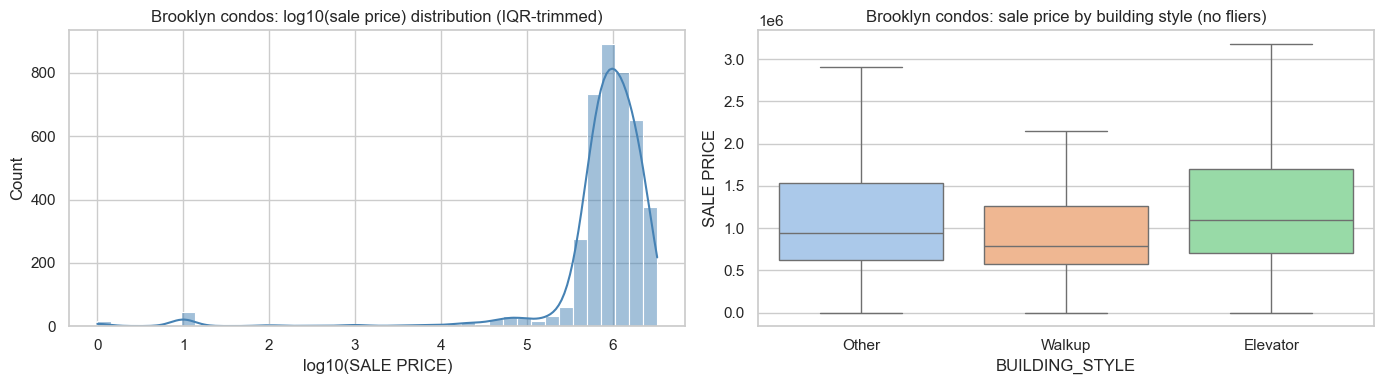

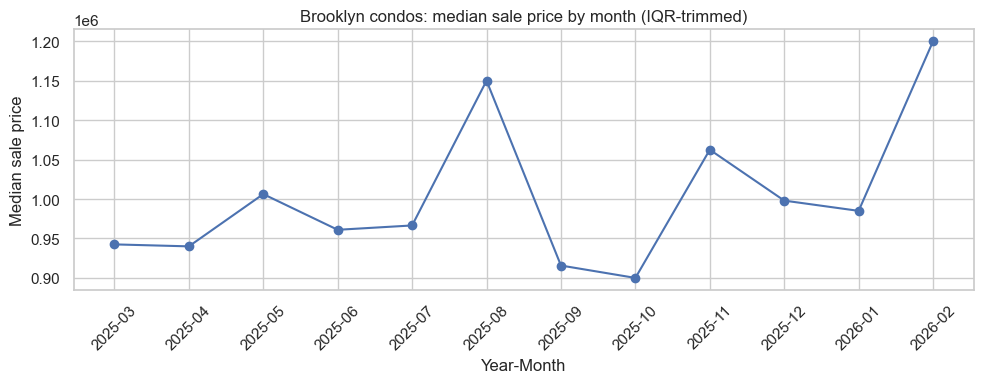

In [9]:
# Visuals
sns.set_theme(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

ax = axs[0]
sns.histplot(np.log10(condo_tp["SALE PRICE"]), bins=40, kde=True, ax=ax, color="steelblue")
ax.set_title("Brooklyn condos: log10(sale price) distribution (IQR-trimmed)")
ax.set_xlabel("log10(SALE PRICE)")

ax = axs[1]
sns.boxplot(data=condo_tp, x="BUILDING_STYLE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
ax.set_title("Brooklyn condos: sale price by building style (no fliers)")
ax.set_ylabel("SALE PRICE")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
monthly = (
    condo_tp.groupby("YEAR_MONTH", sort=True)["SALE PRICE"]
    .median()
    .reset_index()
    .assign(YEAR_MONTH=lambda d: d["YEAR_MONTH"].astype(str))
)
ax.plot(monthly["YEAR_MONTH"], monthly["SALE PRICE"], marker="o")
ax.set_title("Brooklyn condos: median sale price by month (IQR-trimmed)")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Median sale price")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [10]:
# Hedonic-style association: log(SALE PRICE) on single-unit sales only
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

reg_df = condo_tp[condo_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
reg_df = reg_df.dropna(subset=["SALE PRICE", "BUILDING_AGE"])
reg_df = reg_df[reg_df["BUILDING_AGE"] > 0]
reg_df["QUARTER_STR"] = reg_df["QUARTER"].astype(str)

y = np.log(reg_df["SALE PRICE"].to_numpy())
cat_cols = ["BUILDING_STYLE", "BCC_SEGMENT", "QUARTER_STR"]
num_cols = ["BUILDING_AGE"]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)
pipe = Pipeline([("prep", pre), ("ols", LinearRegression())])
pipe.fit(reg_df[cat_cols + num_cols], y)
r2 = pipe.score(reg_df[cat_cols + num_cols], y)

feat_names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pipe.named_steps["ols"].coef_
intercept = pipe.named_steps["ols"].intercept_

print(f"Single-unit rows in regression: {len(reg_df):,}")
print(f"R² (log price): {r2:.3f}")
print(f"Intercept: {intercept:.4f}")
print("\nCoefficients (log $ per unit change in covariate):")
for name, c in zip(feat_names, coefs):
    print(f"  {name}: {c:.5f}")


Single-unit rows in regression: 2,762
R² (log price): 0.019
Intercept: 13.7292

Coefficients (log $ per unit change in covariate):
  cat__BUILDING_STYLE_Other: -0.06390
  cat__BUILDING_STYLE_Walkup: -0.48670
  cat__BCC_SEGMENT_Special billing lots: -5.35278
  cat__QUARTER_STR_2025Q2: -0.06176
  cat__QUARTER_STR_2025Q3: 0.03694
  cat__QUARTER_STR_2025Q4: 0.04717
  cat__QUARTER_STR_2026Q1: 0.20556
  num__BUILDING_AGE: 0.00058
